In [ ]:
# Sales Analysis for AAL's 4th Quarter Data
## Step 1: Data Wrangling
### Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Load the dataset
file_path = "AusApparalSales4thQrt2020.csv"
data = pd.read_csv(file_path)

# Display the first few rows of the dataset
data.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [ ]:
# Check for missing values
print("Checking for missing values:")
print(data.isna().sum())

Checking for missing values:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64


In [ ]:
# Fill missing values with the mean for numerical columns
data['Sales'] = data['Sales'].fillna(data['Sales'].mean())
data['Unit'] = data['Unit'].fillna(data['Unit'].mean())

In [ ]:
# Normalize the Sales and Units columns
scaler = MinMaxScaler()
data[['Sales', 'Unit']] = scaler.fit_transform(data[['Sales', 'Unit']])

# Display the normalized data
data.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,0.015873,0.015873


In [ ]:
# Group data by State and calculate the sum
state_grouped = data.groupby('State').sum()
state_grouped

,Date,Time,Group,Unit,Sales
State,,,,,
NSW,1-Oct-20201-Oct-20201-Oct-20201-Oct-20201-Oct-...,Morning Morning Morning Morning Afternoon Aft...,Kids Men Women Seniors Kids Men Women Seniors...,441.714286,441.714286
NT,1-Oct-20201-Oct-20201-Oct-20201-Oct-20201-Oct-...,Morning Morning Morning Morning Afternoon Aft...,Kids Men Women Seniors Kids Men Women Seniors...,109.079365,109.079365
QLD,1-Oct-20201-Oct-20201-Oct-20201-Oct-20201-Oct-...,Morning Morning Morning Morning Afternoon Aft...,Kids Men Women Seniors Kids Men Women Seniors...,177.888889,177.888889
SA,1-Oct-20201-Oct-20201-Oct-20201-Oct-20201-Oct-...,Morning Morning Morning Morning Afternoon Aft...,Kids Men Women Seniors Kids Men Women Seniors...,339.412698,339.412698
TAS,1-Oct-20201-Oct-20201-Oct-20201-Oct-20201-Oct-...,Morning Morning Morning Morning Afternoon Aft...,Kids Men Women Seniors Kids Men Women Seniors...,110.222222,110.222222
VIC,1-Oct-20201-Oct-20201-Oct-20201-Oct-20201-Oct-...,Morning Morning Morning Morning Afternoon Aft...,Kids Men Women Seniors Kids Men Women Seniors...,635.968254,635.968254
WA,1-Oct-20201-Oct-20201-Oct-20201-Oct-20201-Oct-...,Morning Morning Morning Morning Afternoon Aft...,Kids Men Women Seniors Kids Men Women Seniors...,106.365079,106.365079


In [ ]:
#Data Analytics
# Descriptive statistics for Sales and Units
print("Descriptive statistics for Sales:")
print(data['Sales'].describe())

Descriptive statistics for Sales:
count    7560.000000
mean        0.254054
std         0.204784
min         0.000000
25%         0.095238
50%         0.190476
75%         0.380952
max         1.000000
Name: Sales, dtype: float64


In [ ]:
print("Descriptive statistics for Unit:")
print(data['Unit'].describe())

Descriptive statistics for Unit:
count    7560.000000
mean        0.254054
std         0.204784
min         0.000000
25%         0.095238
50%         0.190476
75%         0.380952
max         1.000000
Name: Unit, dtype: float64


In [ ]:
# Identify states with highest and lowest sales
highest_sales_state = state_grouped['Sales'].idxmax()
lowest_sales_state = state_grouped['Sales'].idxmin()
print(f"State with highest sales: {highest_sales_state}")
print(f"State with lowest sales: {lowest_sales_state}")

State with highest sales:  VIC
State with lowest sales:  WA


In [ ]:
# Convert Date column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Extract Week, Month, and Quarter
data['Week'] = data['Date'].dt.isocalendar().week
data['Month'] = data['Date'].dt.month
data['Quarter'] = data['Date'].dt.quarter

# Generate reports by summing only relevant numerical columns
weekly_report = data.groupby('Week')[['Unit', 'Sales']].sum()
monthly_report = data.groupby('Month')[['Unit', 'Sales']].sum()
quarterly_report = data.groupby('Quarter')[['Unit', 'Sales']].sum()

print("Weekly Report:")
print(weekly_report)
print("Monthly Report:")
print(monthly_report)
print("Quarterly Report:")
print(quarterly_report)

Weekly Report:
            Unit       Sales
Week                        
40     84.857143   84.857143
41    152.777778  152.777778
42    150.476190  150.476190
43    151.587302  151.587302
44    122.460317  122.460317
45    113.809524  113.809524
46    115.761905  115.761905
47    115.380952  115.380952
48    117.698413  117.698413
49    169.412698  169.412698
50    181.492063  181.492063
51    182.317460  182.317460
52    183.047619  183.047619
53     79.571429   79.571429
Monthly Report:
             Unit       Sales
Month                        
10     645.650794  645.650794
11     495.761905  495.761905
12     779.238095  779.238095
Quarterly Report:
                Unit        Sales
Quarter                          
4        1920.650794  1920.650794


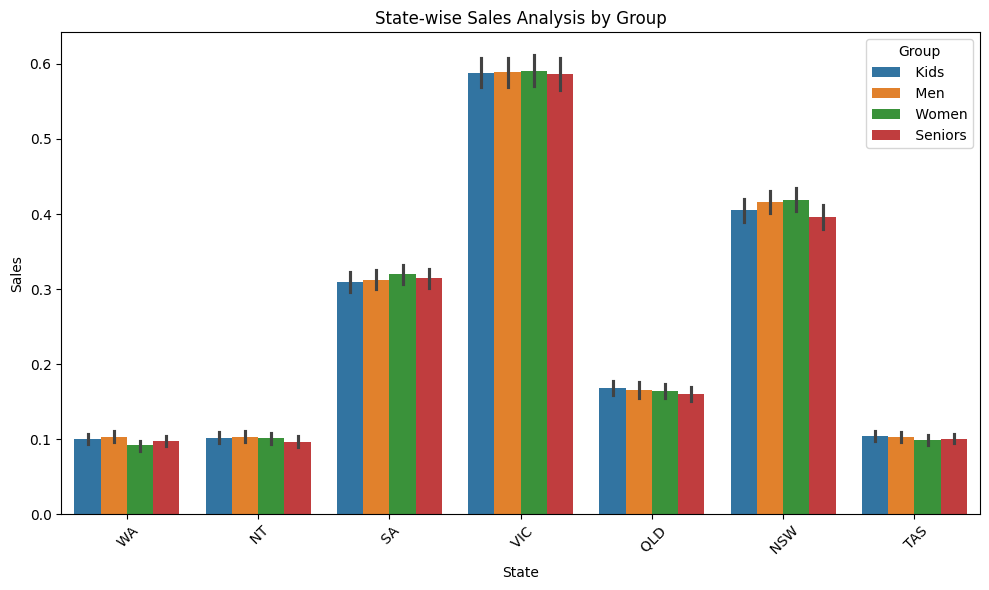

In [ ]:
#Data Visualization
# State-wise sales analysis for different groups
plt.figure(figsize=(10, 6))
sns.barplot(x='State', y='Sales', hue='Group', data=data)
plt.title('State-wise Sales Analysis by Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Part 2

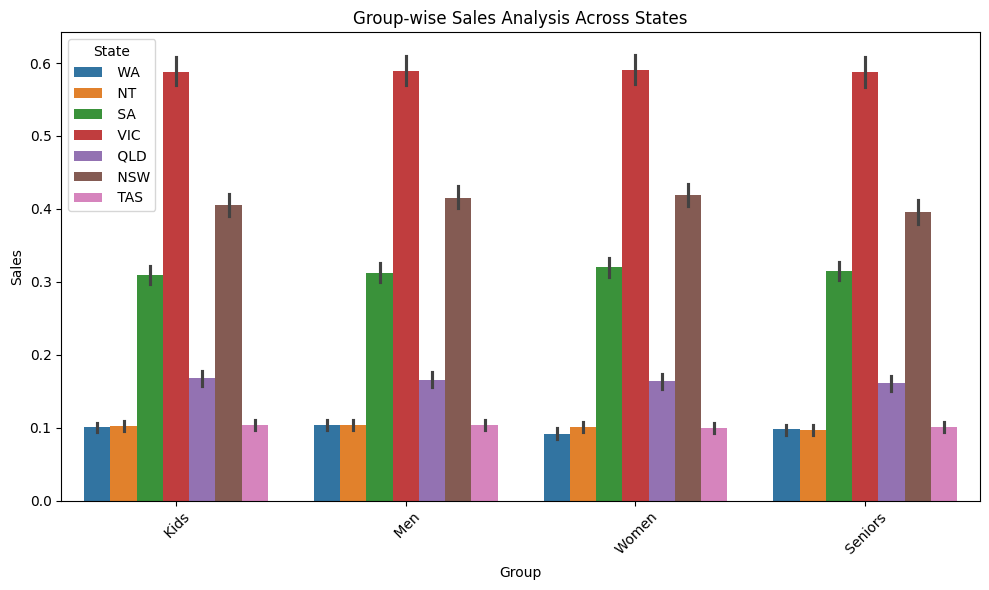

In [ ]:
# Group-wise sales analysis across various states
plt.figure(figsize=(10, 6))
sns.barplot(x='Group', y='Sales', hue='State', data=data)
plt.title('Group-wise Sales Analysis Across States')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

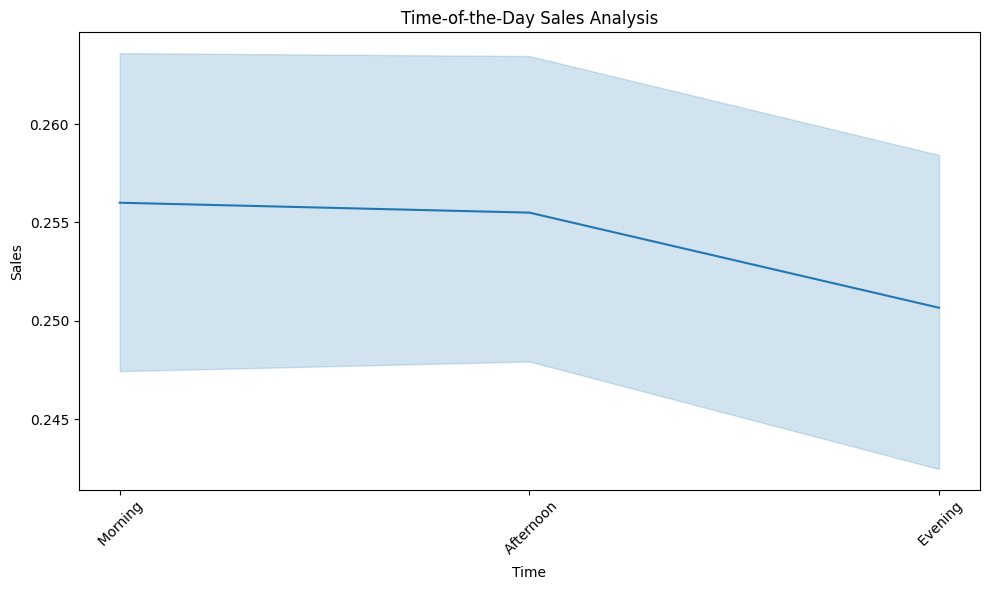

In [ ]:
# Time-of-the-day analysis
plt.figure(figsize=(10, 6))
sns.lineplot(x='Time', y='Sales', data=data)
plt.title('Time-of-the-Day Sales Analysis')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

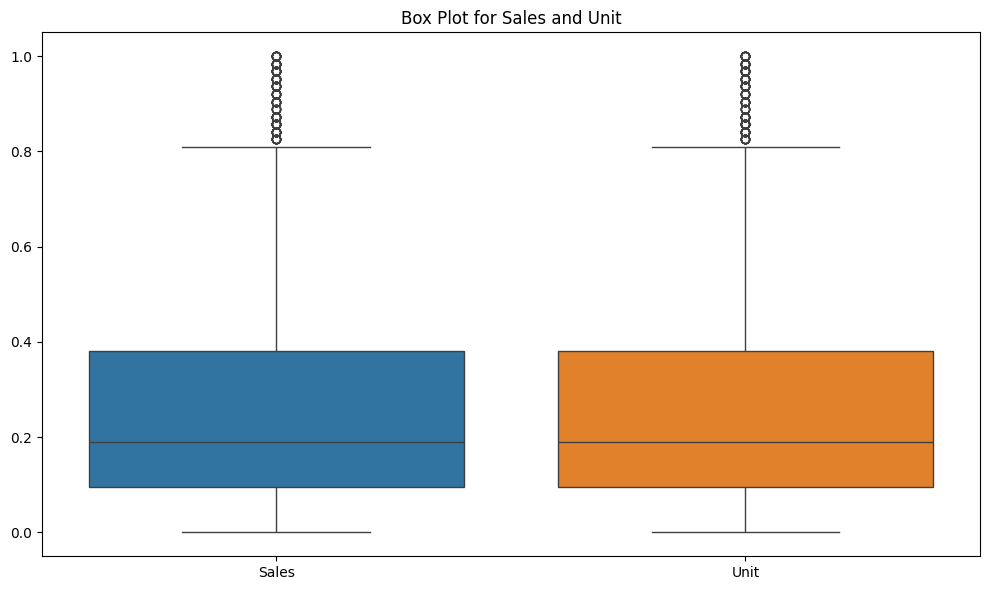

In [ ]:
# Box plot for Sales and Unit
plt.figure(figsize=(10, 6))
sns.boxplot(data=data[['Sales', 'Unit']])
plt.title('Box Plot for Sales and Unit')
plt.tight_layout()
plt.show()